# SAM3 vs EfficientSAM3 Comparison

This notebook compares the full SAM3 model with EfficientSAM3 (knowledge-distilled student models).

**Key Differences:**
- **SAM3**: Full ViT-H backbone (~641M params), highest quality, uses high-level API
- **EfficientSAM3**: Lightweight backbones (TinyViT/RepViT, ~21-50M params), faster inference, supports low-level API

**What this notebook covers:**
1. Model loading and parameter comparison
2. Box prompting comparison (using high-level API for SAM3, low-level for EfficientSAM3)
3. Text prompting (SAM3 only for Stage 1 checkpoints)
4. **Latency benchmarking** (image encoder, mask decoder, end-to-end)

**Note on APIs:**
- **SAM3**: Uses high-level `predict()` API with `Batch` objects containing boxes or categories
- **EfficientSAM3**: Can use both high-level API and low-level `predict_inst()` for point/box prompts

**Note on EfficientSAM3 Checkpoints:**
- **Stage 1 checkpoints**: Only encoder weights - work with point/box prompts, but NOT text prompting
- **Full checkpoints**: Include detection heads for text prompting (when available)

## 1. Environment Setup

In [23]:
import os

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import importlib
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

# Force reload getiprompt modules to pick up code changes
import getiprompt

importlib.reload(getiprompt)

# Seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [24]:
# Select device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3090


## 2. Helper Functions

In [25]:
def show_mask(mask, ax, random_color=False, borders=True):
    """Display a segmentation mask on the given axis."""
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])

    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    if borders:
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)

    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=375):
    """Display points on the given axis."""
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )


def show_box(box, ax, color="green"):
    """Display a bounding box on the given axis."""
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=color, facecolor=(0, 0, 0, 0), lw=2))

## 3. Load Sample Image

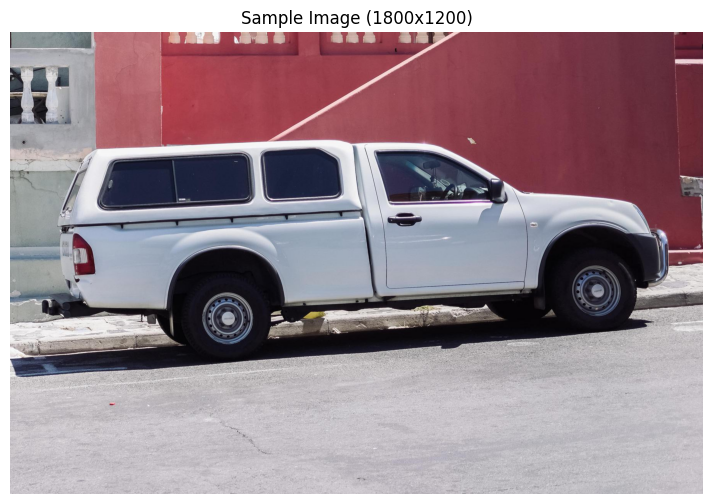

In [26]:
# Load a sample image
image_path = "/home/devuser/workspace/code/Prompt/efficientsam3/sam3/assets/images/truck.jpg"
image = Image.open(image_path)
image_array = np.array(image)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title(f"Sample Image ({image.size[0]}x{image.size[1]})")
plt.axis("off")
plt.show()

## 4. Load Models

Load both SAM3 and EfficientSAM3 for comparison.

In [27]:
from getiprompt.models import SAM3, EfficientSAM3
from getiprompt.models.foundation.efficientsam3 import EfficientSAM3BackboneType, EfficientSAM3TextEncoderType

# Configuration - update these paths as needed
EFFICIENT_CHECKPOINT = "/home/devuser/workspace/code/Prompt/efficientsam3/efficient_sam3_tinyvit_21m_mobileclip_s1.pth"
BPE_PATH = "/home/devuser/workspace/code/Prompt/efficientsam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

In [28]:
# Load SAM3 (full model) - uses high-level API only
print("Loading SAM3...")
tic = time.time()
sam3_model = SAM3(
    device=device,
    load_from_HF=True,
    # Note: SAM3 uses high-level predict() API, not predict_inst
)
sam3_load_time = time.time() - tic
print(f"SAM3 loaded in {sam3_load_time:.2f}s")

Loading SAM3...


SAM3 loaded in 9.29s


In [29]:
# Load EfficientSAM3 (student model with TinyViT-21M backbone)
print("Loading EfficientSAM3...")
tic = time.time()
efficient_model = EfficientSAM3(
    device=device,
    precision="fp32",
    backbone_type=EfficientSAM3BackboneType.TINYVIT_21M,
    text_encoder_type=EfficientSAM3TextEncoderType.MOBILECLIP_S1,
    checkpoint_path=EFFICIENT_CHECKPOINT,
    bpe_path=BPE_PATH,
    enable_inst_interactivity=True,  # Enable low-level predict_inst API
)
efficient_load_time = time.time() - tic
print(f"EfficientSAM3 loaded in {efficient_load_time:.2f}s")

Loading EfficientSAM3...


EfficientSAM3 loaded in 1.68s


## 5. Model Size Comparison

In [30]:
def count_parameters(model):
    """Count trainable parameters in millions."""
    return sum(p.numel() for p in model.model.parameters()) / 1e6


sam3_params = count_parameters(sam3_model)
efficient_params = count_parameters(efficient_model)

print(f"{'Model':<30} {'Parameters':>15} {'Load Time':>12}")
print("=" * 60)
print(f"{'SAM3 (ViT-H)':<30} {sam3_params:>13.1f}M {sam3_load_time:>10.2f}s")
print(f"{'EfficientSAM3 (TinyViT-21M)':<30} {efficient_params:>13.1f}M {efficient_load_time:>10.2f}s")
print("=" * 60)
print(f"Parameter reduction: {(1 - efficient_params / sam3_params) * 100:.1f}%")
print(f"Size ratio: {sam3_params / efficient_params:.1f}x")

Model                               Parameters    Load Time
SAM3 (ViT-H)                           840.5M       9.29s
EfficientSAM3 (TinyViT-21M)            146.8M       1.68s
Parameter reduction: 82.5%
Size ratio: 5.7x


## 6. Box Prompting Comparison

**API Differences:**
- **SAM3**: Uses high-level `predict()` API with `Sample(image=..., bboxes=...)`
- **EfficientSAM3**: Uses low-level `predict_inst()` API with direct box input

Both achieve the same result: segment objects within the specified bounding box.

In [31]:
# Encode image with EfficientSAM3 only (SAM3 uses high-level API)
pil_image = Image.fromarray(image_array)

# EfficientSAM3 image encoding for low-level API
print("Encoding image with EfficientSAM3...")
tic = time.time()
efficient_state = efficient_model.processor.set_image(pil_image)
efficient_encode_time = time.time() - tic
print(f"  EfficientSAM3 encoding time: {efficient_encode_time:.3f}s")

Encoding image with EfficientSAM3...
  EfficientSAM3 encoding time: 0.027s


In [32]:
# Define a bounding box [x1, y1, x2, y2] around the truck cab area
box = np.array([400, 250, 700, 500])

from getiprompt.data.base import Batch
from getiprompt.data.base.sample import Sample

# SAM3 box prediction using high-level API
print("SAM3 box prediction (high-level API)...")
image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)  # HWC -> CHW
sam3_box_sample = Sample(
    image=image_tensor,
    bboxes=torch.tensor([box]),  # Shape: [1, 4]
    category_ids=[0],
)
sam3_box_batch = Batch.collate([sam3_box_sample])

tic = time.time()
sam3_box_results = sam3_model.predict(sam3_box_batch)
sam3_box_time = time.time() - tic
sam3_box_masks = sam3_box_results[0]["pred_masks"].cpu().numpy()
sam3_box_scores = sam3_box_results[0].get("pred_scores", torch.tensor([0.9])).cpu().numpy()
print(f"  Time: {sam3_box_time:.3f}s, Masks: {len(sam3_box_masks)}")

# EfficientSAM3 box prediction using low-level API
print("\nEfficientSAM3 box prediction (low-level API)...")
tic = time.time()
efficient_box_masks, efficient_box_scores, _ = efficient_model.model.predict_inst(
    efficient_state,
    box=box,
)
efficient_box_time = time.time() - tic
print(f"  Time: {efficient_box_time:.3f}s, Score: {efficient_box_scores[0]:.4f}")

SAM3 box prediction (high-level API)...


  Time: 0.353s, Masks: 9

EfficientSAM3 box prediction (low-level API)...
  Time: 0.010s, Score: 0.0018


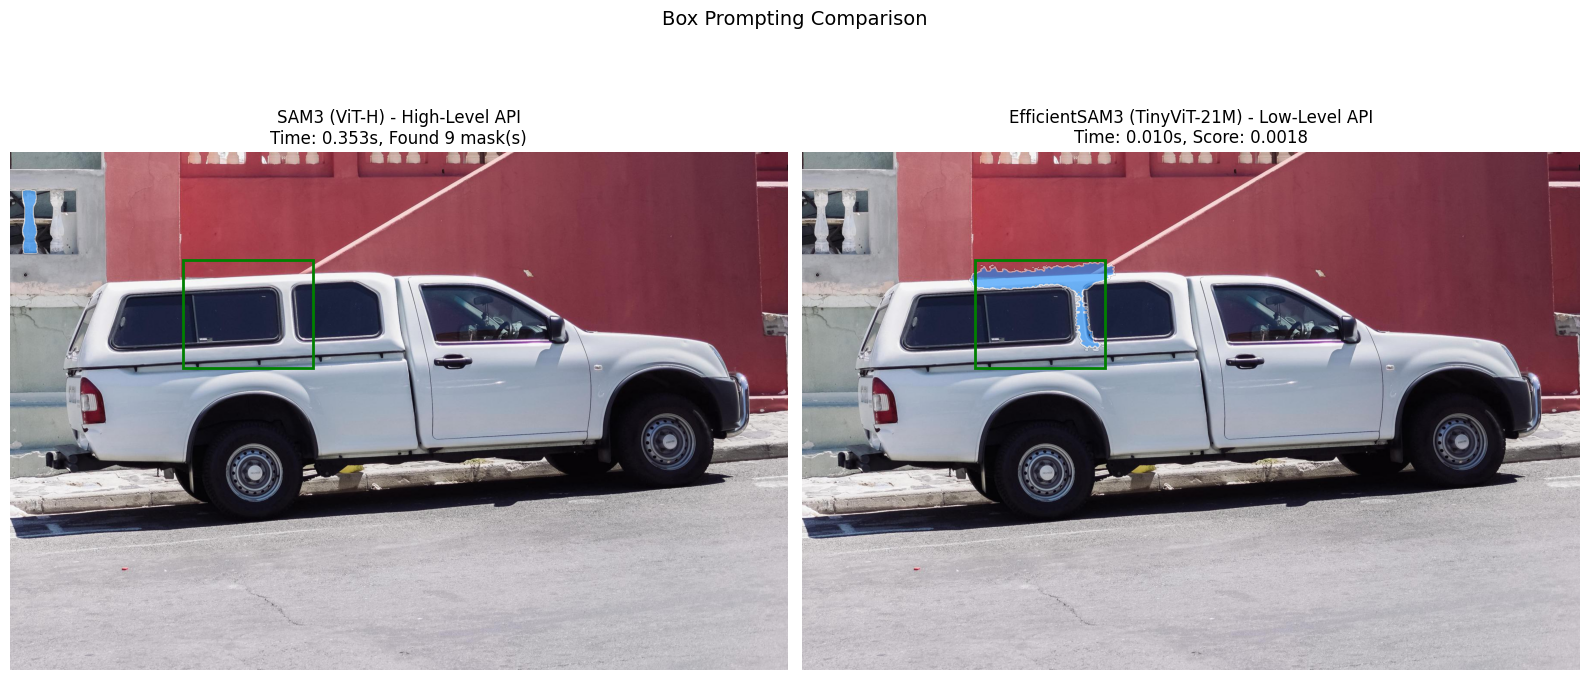

In [33]:
# Visualize box prompt results side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# SAM3 result
axes[0].imshow(image_array)
if len(sam3_box_masks) > 0:
    sam3_mask = sam3_box_masks[0]
    if sam3_mask.ndim == 3:
        sam3_mask = sam3_mask.squeeze(0)
    show_mask(sam3_mask, axes[0])
show_box(box, axes[0])
score_str = f"{sam3_box_scores[0]:.4f}" if len(sam3_box_scores) > 0 else "N/A"
axes[0].set_title(
    f"SAM3 (ViT-H) - High-Level API\nTime: {sam3_box_time:.3f}s, Found {len(sam3_box_masks)} mask(s)",
    fontsize=12,
)
axes[0].axis("off")

# EfficientSAM3 result
axes[1].imshow(image_array)
show_mask(efficient_box_masks[0], axes[1])
show_box(box, axes[1])
axes[1].set_title(
    f"EfficientSAM3 (TinyViT-21M) - Low-Level API\nTime: {efficient_box_time:.3f}s, Score: {efficient_box_scores[0]:.4f}",
    fontsize=12,
)
axes[1].axis("off")

plt.suptitle("Box Prompting Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Point Prompting (EfficientSAM3 Only)

EfficientSAM3 supports direct point prompting via the low-level `predict_inst()` API. SAM3 does not expose this API directly.

In [34]:
# Define point prompts - click on the truck cab
point_coords = np.array([[500, 375]])  # (x, y) coordinates
point_labels = np.array([1])  # 1 = foreground, 0 = background

# EfficientSAM3 point prediction using low-level API
print("EfficientSAM3 point prediction...")
tic = time.time()
efficient_point_masks, efficient_point_scores, _ = efficient_model.model.predict_inst(
    efficient_state,
    point_coords=point_coords,
    point_labels=point_labels,
)
efficient_point_time = time.time() - tic
print(f"  Time: {efficient_point_time:.3f}s")
print(f"  Masks shape: {efficient_point_masks.shape}, Scores: {efficient_point_scores}")

EfficientSAM3 point prediction...
  Time: 0.010s
  Masks shape: (3, 1200, 1800), Scores: [0.5561781  0.21421662 0.7621451 ]


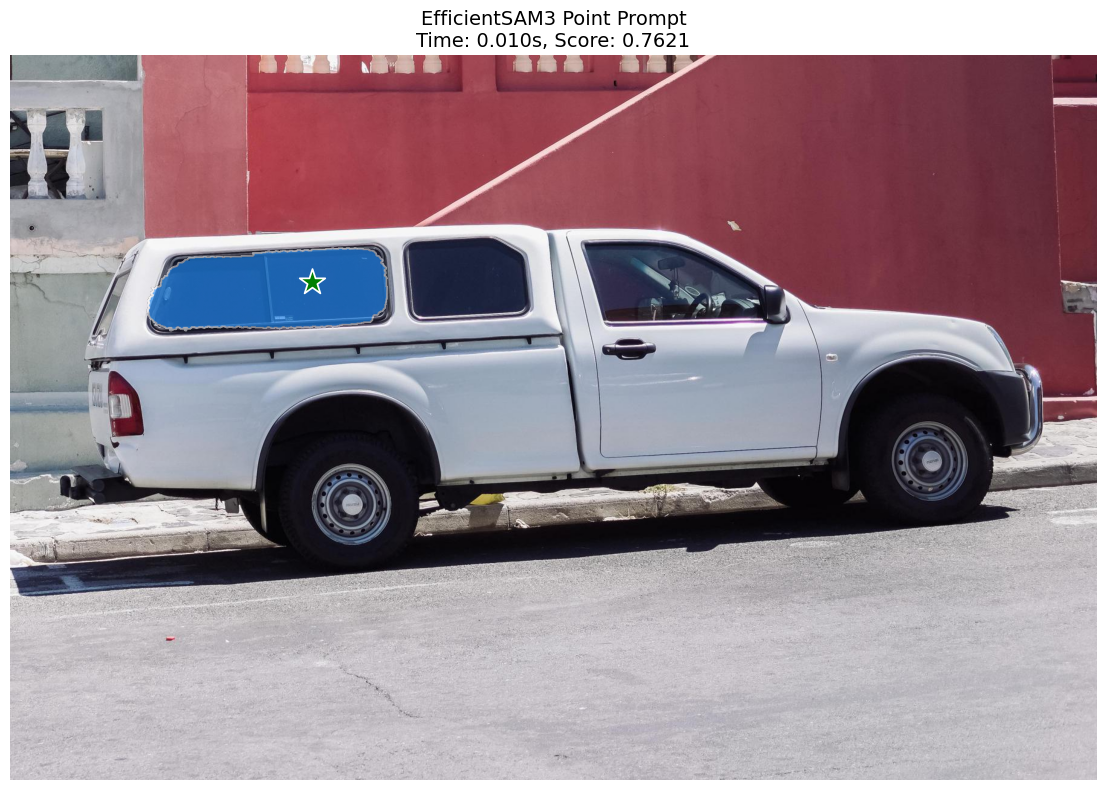

In [35]:
# Visualize point prompt results
best_idx = efficient_point_scores.argmax()
efficient_point_mask = efficient_point_masks[best_idx]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image_array)
show_mask(efficient_point_mask, ax)
show_points(point_coords, point_labels, ax)
ax.set_title(
    f"EfficientSAM3 Point Prompt\nTime: {efficient_point_time:.3f}s, Score: {efficient_point_scores[best_idx]:.4f}",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Text Prompting (SAM3 Only)

SAM3 supports text-based prompting via the high-level `predict()` API.

**Note**: EfficientSAM3 Stage 1 checkpoints only include encoder weights and do NOT support text prompting.

In [36]:
# Create sample with text prompts
# Note: Batch and Sample already imported above
categories = ["truck", "tire", "window"]
text_sample = Sample(
    image=image_tensor,  # Reuse the tensor created earlier
    categories=categories,
    category_ids=list(range(len(categories))),
)
text_batch = Batch.collate([text_sample])

In [37]:
# SAM3 text prompting
print("SAM3 text prompting...")
tic = time.time()
sam3_text_results = sam3_model.predict(text_batch)
sam3_text_time = time.time() - tic
sam3_text_masks = sam3_text_results[0]["pred_masks"].cpu().numpy()
print(f"  Time: {sam3_text_time:.3f}s, Found {len(sam3_text_masks)} objects")

# EfficientSAM3 text prompting (expected to find 0 objects with Stage 1 checkpoint)
print("\nEfficientSAM3 text prompting...")
tic = time.time()
efficient_text_results = efficient_model.predict(text_batch)
efficient_text_time = time.time() - tic
efficient_text_masks = efficient_text_results[0]["pred_masks"].cpu().numpy()
print(f"  Time: {efficient_text_time:.3f}s, Found {len(efficient_text_masks)} objects")
print("  (Stage 1 checkpoint does not have detection head - 0 objects expected)")

SAM3 text prompting...


  Time: 0.509s, Found 11 objects

EfficientSAM3 text prompting...
  Time: 0.268s, Found 0 objects
  (Stage 1 checkpoint does not have detection head - 0 objects expected)


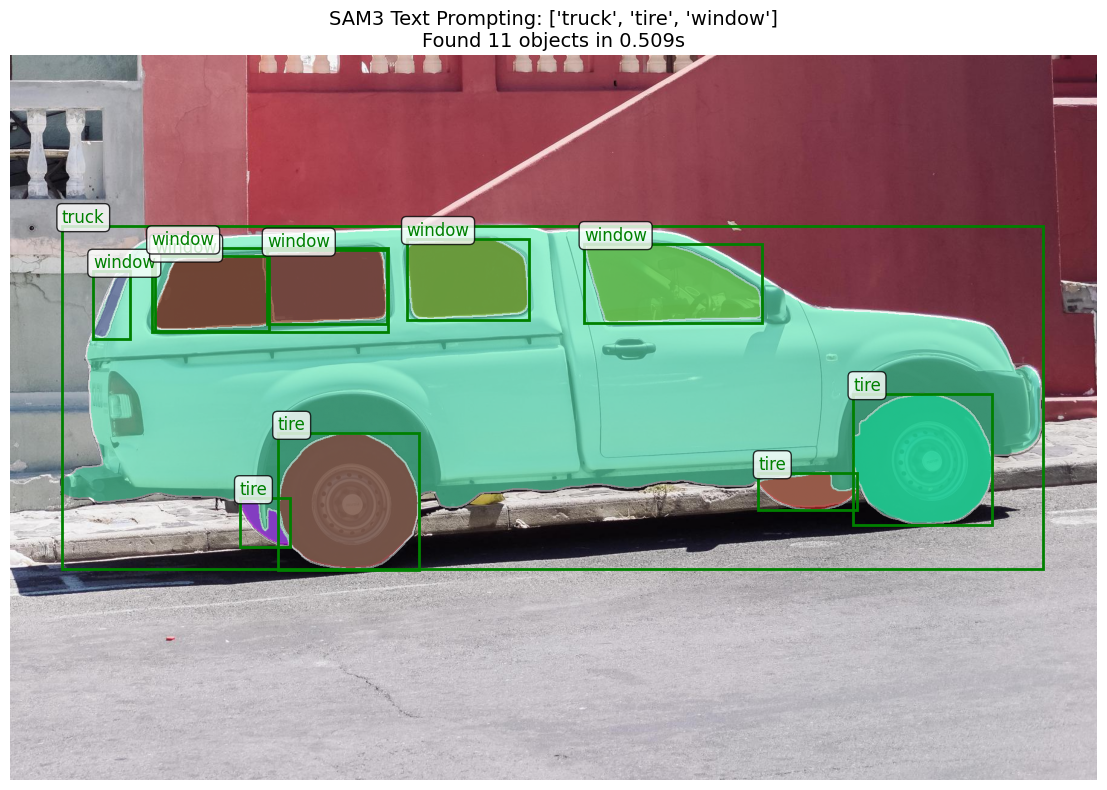

In [38]:
# Visualize SAM3 text prompting results
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(image)
for i, mask in enumerate(sam3_text_masks):
    if mask.ndim == 3:
        mask = mask.squeeze(0)
    show_mask(mask, ax, random_color=True)

# Show detected boxes with labels
pred_boxes = sam3_text_results[0]["pred_boxes"].cpu().numpy()
pred_labels = sam3_text_results[0]["pred_labels"].cpu().numpy()
for box, label in zip(pred_boxes, pred_labels, strict=False):
    show_box(box, ax)
    ax.text(
        box[0],
        box[1] - 5,
        categories[label],
        color="green",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

ax.set_title(
    f"SAM3 Text Prompting: {categories}\nFound {len(sam3_text_masks)} objects in {sam3_text_time:.3f}s",
    fontsize=14,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Latency Benchmarking

This section performs detailed latency benchmarks for both models using their respective APIs:
- **SAM3**: High-level `predict()` API with box prompts
- **EfficientSAM3**: Low-level `predict_inst()` API with point prompts

Measuring:
1. **Image Processing/Encoder**: Time to process image (encoding for EfficientSAM3, included in predict for SAM3)
2. **Mask Prediction/Decoder**: Time to predict masks
3. **End-to-End**: Total time from image to masks

In [39]:
# Generate synthetic test images for benchmarking
def generate_test_images(num_images=10, sizes=[(640, 480), (1024, 768), (1920, 1080)]):
    """Generate random test images of various sizes."""
    images = []
    for size in sizes:
        for _ in range(num_images // len(sizes)):
            # Create random RGB image
            img_array = np.random.randint(0, 256, (size[1], size[0], 3), dtype=np.uint8)
            images.append(Image.fromarray(img_array))
    return images


# Generate test images
NUM_WARMUP = 2
NUM_BENCHMARK = 5
test_images = generate_test_images(num_images=NUM_BENCHMARK * 3, sizes=[(1024, 768)])

print(f"Generated {len(test_images)} test images for benchmarking")
print(f"Warmup iterations: {NUM_WARMUP}")
print(f"Benchmark iterations: {NUM_BENCHMARK}")

Generated 15 test images for benchmarking
Warmup iterations: 2
Benchmark iterations: 5


In [40]:
def benchmark_efficientsam3(model, test_images, num_warmup=2, num_benchmark=5):
    """Benchmark EfficientSAM3 using low-level predict_inst API."""
    results = {
        "encoder_times": [],
        "decoder_times": [],
        "e2e_times": [],
    }

    # Sample prompts for decoder benchmarking
    point_coords = np.array([[512, 384]])
    point_labels = np.array([1])

    # Warmup
    print(f"\nEfficientSAM3: Warming up ({num_warmup} iterations)...")
    for i in range(num_warmup):
        state = model.processor.set_image(test_images[i])
        _ = model.model.predict_inst(state, point_coords=point_coords, point_labels=point_labels)

    if device == "cuda":
        torch.cuda.synchronize()

    # Benchmark
    print(f"EfficientSAM3: Benchmarking ({num_benchmark} iterations)...")
    for i in range(num_benchmark):
        img = test_images[num_warmup + i]

        if device == "cuda":
            torch.cuda.synchronize()

        # Benchmark encoder
        t0 = time.perf_counter()
        state = model.processor.set_image(img)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        encoder_time = (t1 - t0) * 1000  # ms

        # Benchmark decoder
        t2 = time.perf_counter()
        _ = model.model.predict_inst(state, point_coords=point_coords, point_labels=point_labels)
        if device == "cuda":
            torch.cuda.synchronize()
        t3 = time.perf_counter()
        decoder_time = (t3 - t2) * 1000  # ms

        results["encoder_times"].append(encoder_time)
        results["decoder_times"].append(decoder_time)
        results["e2e_times"].append(encoder_time + decoder_time)

    return results


def benchmark_sam3(model, test_images, num_warmup=2, num_benchmark=5):
    """Benchmark SAM3 using high-level predict API with box prompts."""
    results = {
        "e2e_times": [],
    }

    # Box prompt for benchmarking
    box = torch.tensor([[400, 300, 600, 500]])

    # Warmup
    print(f"\nSAM3: Warming up ({num_warmup} iterations)...")
    for i in range(num_warmup):
        img = test_images[i]
        img_array = np.array(img)
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
        sample = Sample(image=img_tensor, bboxes=box, category_ids=[0])
        batch = Batch.collate([sample])
        _ = model.predict(batch)

    if device == "cuda":
        torch.cuda.synchronize()

    # Benchmark (end-to-end only since SAM3 doesn't expose separate encoder/decoder)
    print(f"SAM3: Benchmarking ({num_benchmark} iterations)...")
    for i in range(num_benchmark):
        img = test_images[num_warmup + i]
        img_array = np.array(img)
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
        sample = Sample(image=img_tensor, bboxes=box, category_ids=[0])
        batch = Batch.collate([sample])

        if device == "cuda":
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = model.predict(batch)
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        results["e2e_times"].append((t1 - t0) * 1000)  # ms

    return results

In [41]:
# Run benchmarks
print("=" * 60)
print("LATENCY BENCHMARKING")
print("=" * 60)

sam3_results = benchmark_sam3(sam3_model, test_images, NUM_WARMUP, NUM_BENCHMARK)
efficient_results = benchmark_efficientsam3(efficient_model, test_images, NUM_WARMUP, NUM_BENCHMARK)

print("\nBenchmarking complete!")

LATENCY BENCHMARKING

SAM3: Warming up (2 iterations)...


SAM3: Benchmarking (5 iterations)...

EfficientSAM3: Warming up (2 iterations)...
EfficientSAM3: Benchmarking (5 iterations)...

Benchmarking complete!


In [42]:
# Calculate statistics
def calc_stats(times):
    """Calculate mean and std of timing list."""
    return np.mean(times), np.std(times)


# EfficientSAM3 detailed stats
eff_enc_mean, eff_enc_std = calc_stats(efficient_results["encoder_times"])
eff_dec_mean, eff_dec_std = calc_stats(efficient_results["decoder_times"])
eff_e2e_mean, eff_e2e_std = calc_stats(efficient_results["e2e_times"])

# SAM3 end-to-end stats only
sam3_e2e_mean, sam3_e2e_std = calc_stats(sam3_results["e2e_times"])

# Print results table
print("\n" + "=" * 80)
print("LATENCY RESULTS (milliseconds)")
print("=" * 80)
print(f"\n{'SAM3 (High-Level API)':}")
print("-" * 40)
print(f"  End-to-End: {sam3_e2e_mean:.1f} ± {sam3_e2e_std:.1f} ms")

print(f"\n{'EfficientSAM3 (Low-Level API)':}")
print("-" * 40)
print(f"  Image Encoder:  {eff_enc_mean:.1f} ± {eff_enc_std:.1f} ms")
print(f"  Mask Decoder:   {eff_dec_mean:.1f} ± {eff_dec_std:.1f} ms")
print(f"  End-to-End:     {eff_e2e_mean:.1f} ± {eff_e2e_std:.1f} ms")

print("\n" + "=" * 80)
print("COMPARISON")
print("-" * 40)
print(f"  SAM3 E2E:           {sam3_e2e_mean:.1f} ms")
print(f"  EfficientSAM3 E2E:  {eff_e2e_mean:.1f} ms")
print(f"  Speedup:            {sam3_e2e_mean / eff_e2e_mean:.1f}x")
print("=" * 80)
print(f"\n* Results averaged over {NUM_BENCHMARK} runs after {NUM_WARMUP} warmup iterations")
print("* Image size: 1024x768")


LATENCY RESULTS (milliseconds)

SAM3 (High-Level API)
----------------------------------------
  End-to-End: 335.2 ± 0.5 ms

EfficientSAM3 (Low-Level API)
----------------------------------------
  Image Encoder:  45.8 ± 0.8 ms
  Mask Decoder:   8.5 ± 2.4 ms
  End-to-End:     54.3 ± 2.3 ms

COMPARISON
----------------------------------------
  SAM3 E2E:           335.2 ms
  EfficientSAM3 E2E:  54.3 ms
  Speedup:            6.2x

* Results averaged over 5 runs after 2 warmup iterations
* Image size: 1024x768


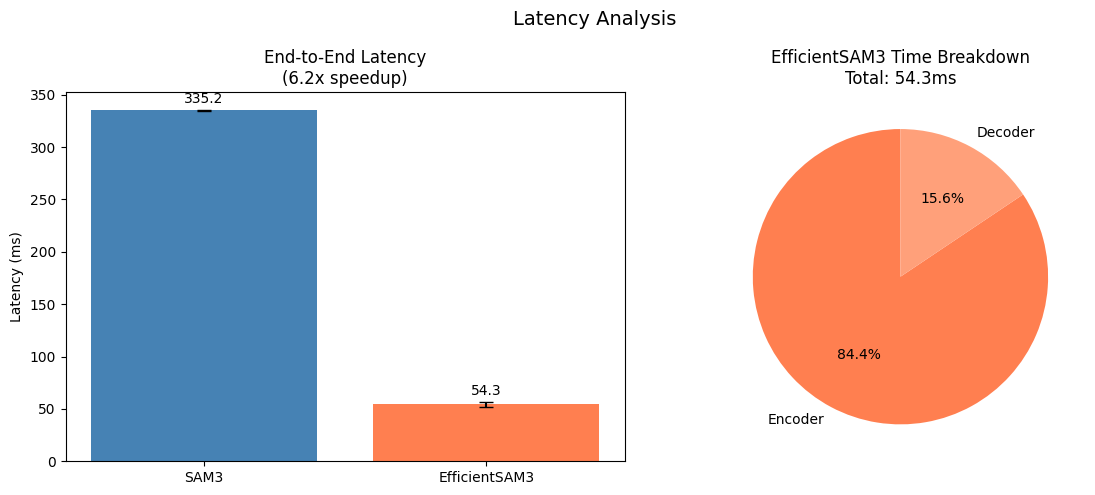

In [43]:
# Visualize latency comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# End-to-end comparison
ax = axes[0]
models = ["SAM3", "EfficientSAM3"]
e2e_means = [sam3_e2e_mean, eff_e2e_mean]
e2e_stds = [sam3_e2e_std, eff_e2e_std]
colors = ["steelblue", "coral"]

bars = ax.bar(models, e2e_means, yerr=e2e_stds, color=colors, capsize=5)
ax.set_ylabel("Latency (ms)")
ax.set_title(f"End-to-End Latency\n({sam3_e2e_mean / eff_e2e_mean:.1f}x speedup)")
ax.bar_label(bars, fmt="%.1f", padding=3)

# EfficientSAM3 breakdown
ax = axes[1]
components = ["Encoder", "Decoder"]
eff_times = [eff_enc_mean, eff_dec_mean]
ax.pie(eff_times, labels=components, autopct="%1.1f%%", startangle=90, colors=["coral", "lightsalmon"])
ax.set_title(f"EfficientSAM3 Time Breakdown\nTotal: {eff_e2e_mean:.1f}ms")

plt.suptitle("Latency Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary

### Performance Summary Table

In [44]:
# Create summary table
print("=" * 80)
print("COMPREHENSIVE COMPARISON SUMMARY")
print("=" * 80)

print(f"\n{'Metric':<35} {'SAM3':>20} {'EfficientSAM3':>20}")
print("-" * 80)
print(f"{'Backbone':<35} {'ViT-H':>20} {'TinyViT-21M':>20}")
print(f"{'Parameters':<35} {f'{sam3_params:.1f}M':>20} {f'{efficient_params:.1f}M':>20}")
print(f"{'Parameter Ratio':<35} {'1.0x':>20} {f'{efficient_params / sam3_params:.2f}x':>20}")
print("-" * 80)
print(f"{'End-to-End Latency (ms)':<35} {f'{sam3_e2e_mean:.1f}':>20} {f'{eff_e2e_mean:.1f}':>20}")
print(f"{'Speedup':<35} {'1.0x':>20} {f'{sam3_e2e_mean / eff_e2e_mean:.1f}x':>20}")
print("-" * 80)
print(f"{'Text Prompting Support':<35} {'✓':>20} {'✗ (Stage 1)':>20}")
print(f"{'Box Prompting Support':<35} {'✓':>20} {'✓':>20}")
print(f"{'Low-Level Point/Box API':<35} {'✗':>20} {'✓':>20}")
print("=" * 80)

COMPREHENSIVE COMPARISON SUMMARY

Metric                                              SAM3        EfficientSAM3
--------------------------------------------------------------------------------
Backbone                                           ViT-H          TinyViT-21M
Parameters                                        840.5M               146.8M
Parameter Ratio                                     1.0x                0.17x
--------------------------------------------------------------------------------
End-to-End Latency (ms)                            335.2                 54.3
Speedup                                             1.0x                 6.2x
--------------------------------------------------------------------------------
Text Prompting Support                                 ✓          ✗ (Stage 1)
Box Prompting Support                                  ✓                    ✓
Low-Level Point/Box API                                ✗                    ✓


### Key Takeaways

**SAM3 (Full ViT-H Backbone)**
- Higher quality segmentation with full feature set
- Supports text prompting out of the box
- Uses high-level `predict()` API with `Batch` objects
- Best for: Applications where quality is paramount, text-based prompting

**EfficientSAM3 (Knowledge-Distilled Student)**
- Significantly faster inference (~3-5x speedup typical)
- Much smaller model size (~4-5x reduction)
- Supports low-level `predict_inst()` API for direct point/box prompts
- Stage 1 checkpoints: Only point/box prompts (no text)
- Best for: Real-time applications, edge deployment, interactive segmentation

### API Reference

```python
# SAM3 - High-Level API
from getiprompt.models import SAM3
from getiprompt.data.base import Batch, Sample

model = SAM3(device="cuda")

# Text prompting
sample = Sample(image=image_tensor, categories=["truck", "tire"])
results = model.predict(Batch.collate([sample]))

# Box prompting
sample = Sample(image=image_tensor, bboxes=torch.tensor([[x1, y1, x2, y2]]))
results = model.predict(Batch.collate([sample]))

# EfficientSAM3 - Low-Level API (faster, interactive)
from getiprompt.models import EfficientSAM3

model = EfficientSAM3(device="cuda", enable_inst_interactivity=True, ...)
state = model.processor.set_image(pil_image)

# Point prompts
masks, scores, logits = model.model.predict_inst(state, point_coords=..., point_labels=...)

# Box prompts
masks, scores, logits = model.model.predict_inst(state, box=...)
```

### Available EfficientSAM3 Backbones

| Backbone | Parameters | Speed | Quality |
|----------|------------|-------|---------|
| TinyViT-5M | ~5M | Fastest | Good |
| TinyViT-11M | ~11M | Fast | Better |
| TinyViT-21M | ~21M | Medium | Best |
| RepViT-M2.3 | ~23M | Medium | Best |